# Clustering

Trying multiple clustering approaches and visualizing the results using T-SNE. For finding the optimal number of clusters we choose Silhouette Method and Elbow Method where possible. 

## Imports

In [3]:
import os

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import cdist, pdist
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score, pairwise_distances
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings("ignore")
 
import utils

## Loading the Data

In [4]:
df = pd.read_csv("../Data/final_cleaned_dataset.csv", index_col=0)

labels_df = df[['CountryCode', 'CountryName']]
numerical_features_df = df.drop(columns=['CountryCode', 'CountryName'])

In [5]:
numerical_features_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 89 entries, 0 to 88
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   TourismEmploymentPer1000  89 non-null     float64
 1   TourismGDPPercentage      89 non-null     float64
 2   BusinessToPersonalRatio   89 non-null     float64
 3   AverageStayDays           89 non-null     float64
 4   InboundArrivalsPer1000    89 non-null     float64
 5   DomesticTouristsPer1000   89 non-null     float64
 6   InboundToOutboundRatio    89 non-null     float64
 7   GroceriesCostIndex        89 non-null     float64
 8   RestaurantPriceIndex      89 non-null     float64
 9   SafetyIndex               89 non-null     float64
 10  HealthCareIndex           89 non-null     float64
 11  ClimateIndex              89 non-null     float64
 12  ReverseTrafficIndex       89 non-null     float64
 13  ReversePollutionIndex     89 non-null     float64
dtypes: float64(14)
me

## K-Means Clustering

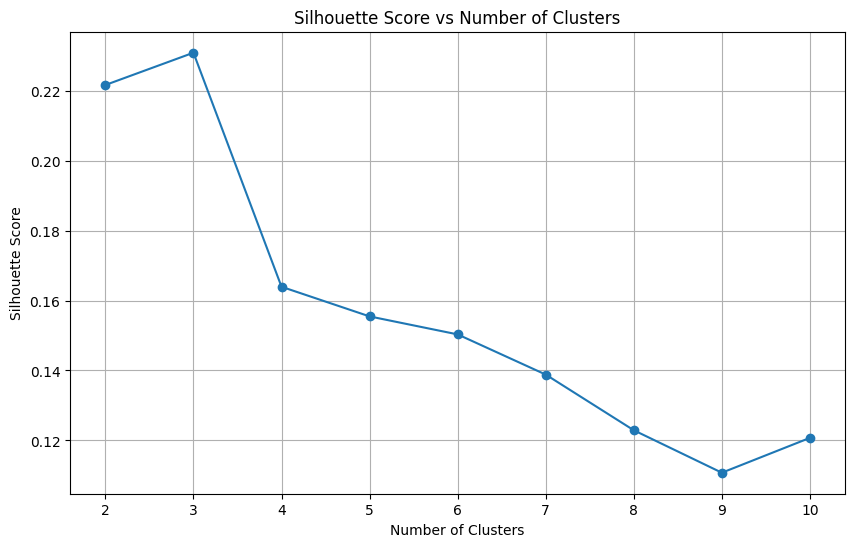

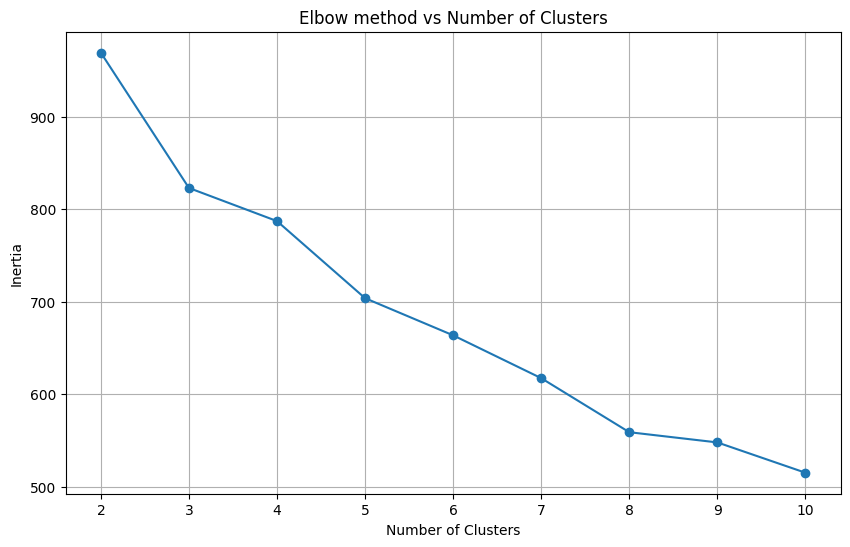

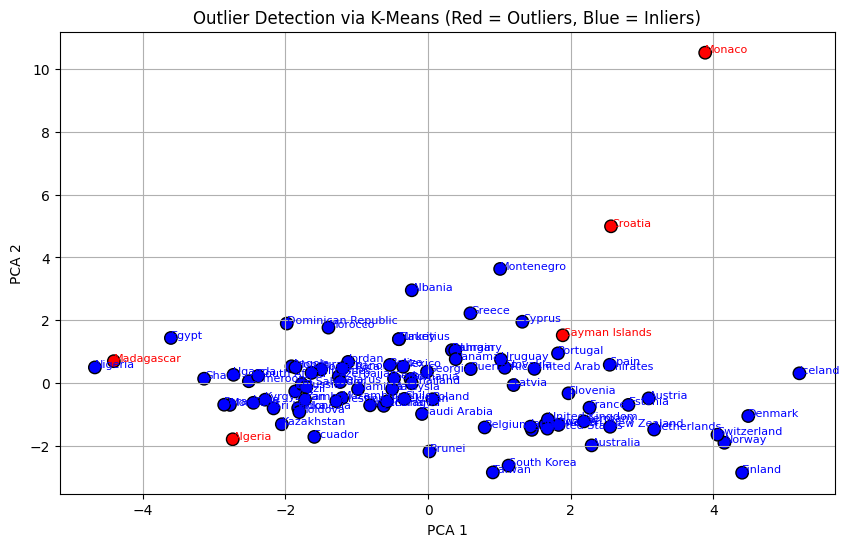

Outlier Countries:
['Algeria', 'Cayman Islands', 'Croatia', 'Madagascar', 'Monaco']


In [6]:
number_clusters = range(2, 11) #between 2 and 11 clusters
silhouette_scores, inertia = utils.getSilhouetteScoreAndInertiaForKMeans(number_clusters, numerical_features_df)
utils.plotValuesBasedOnClusterNumbers(number_clusters, silhouette_scores, "Number of Clusters", "Silhouette Score","Silhouette Score vs Number of Clusters")
utils.plotValuesBasedOnClusterNumbers(number_clusters, inertia, "Number of Clusters", "Inertia","Elbow method vs Number of Clusters")

#Choose the best k (based on max silhouette score)
best_k = number_clusters[inertia.index(max(inertia))]

#Run K-Means
kmeans_final = KMeans(n_clusters=best_k,random_state=43, n_init=10, max_iter=1000)
cluster_labels = kmeans_final.fit_predict(numerical_features_df)


# Get distances of each point to its assigned cluster centroid
centroids = kmeans_final.cluster_centers_
distances = np.linalg.norm(numerical_features_df - centroids[cluster_labels], axis=1)

# Define outliers (e.g., top 5% farthest points)
threshold = np.percentile(distances, 95)
outliers = distances > threshold

# Run PCA
pca = PCA(n_components=2)
pca_components = pca.fit_transform(numerical_features_df)

plt.figure(figsize=(10, 6))

# Color points: red for outliers, blue otherwise
colors = ['red' if outliers[i] else 'blue' for i in range(len(outliers))]
plt.scatter(pca_components[:, 0], pca_components[:, 1], c=colors, s=80, edgecolors='k')

# Annotate country names using same red/blue logic
for i, country in enumerate(df["CountryName"]):
    label_color = 'red' if outliers[i] else 'blue'
    plt.annotate(country, (pca_components[i, 0], pca_components[i, 1]), fontsize=8, color=label_color)

plt.title("Outlier Detection via K-Means (Red = Outliers, Blue = Inliers)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.grid(True)
plt.show()

# Print names of outlier countries
outlier_countries = df["CountryName"][outliers]
print("Outlier Countries:")
print(outlier_countries.to_list())

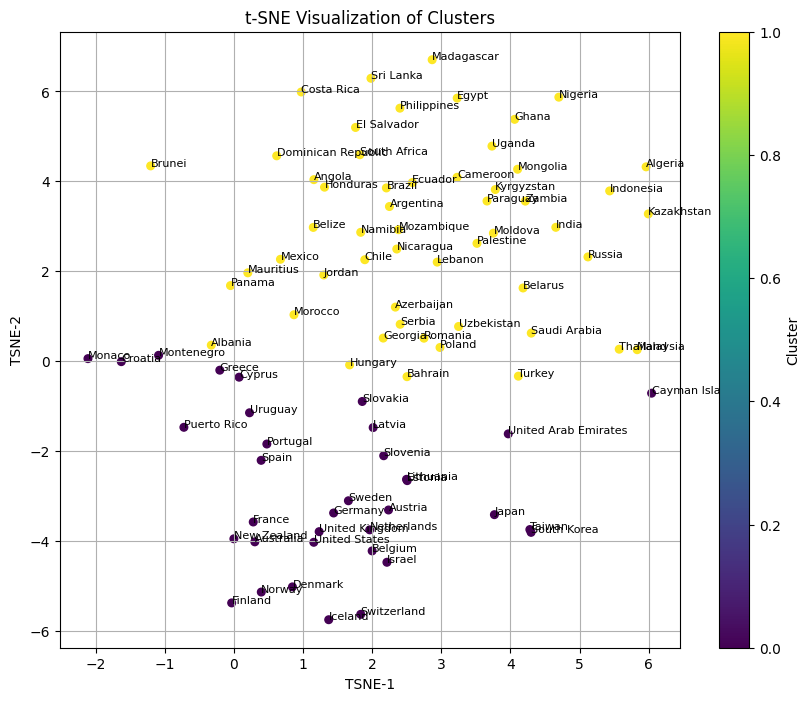

In [7]:

utils.applyTSNE(numerical_features_df, cluster_labels, df)

## Agglomerative Clustering

## DBScan

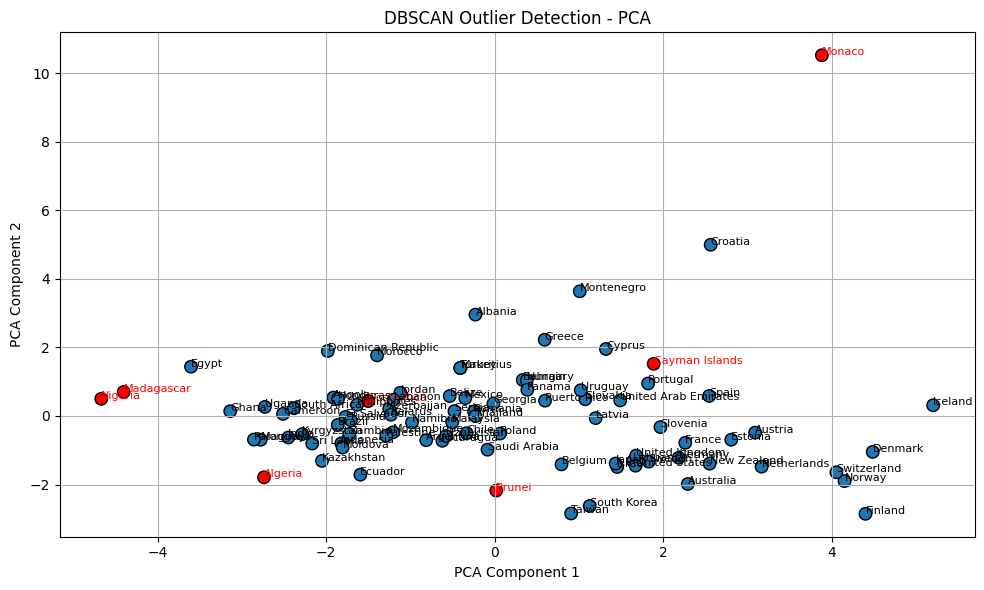

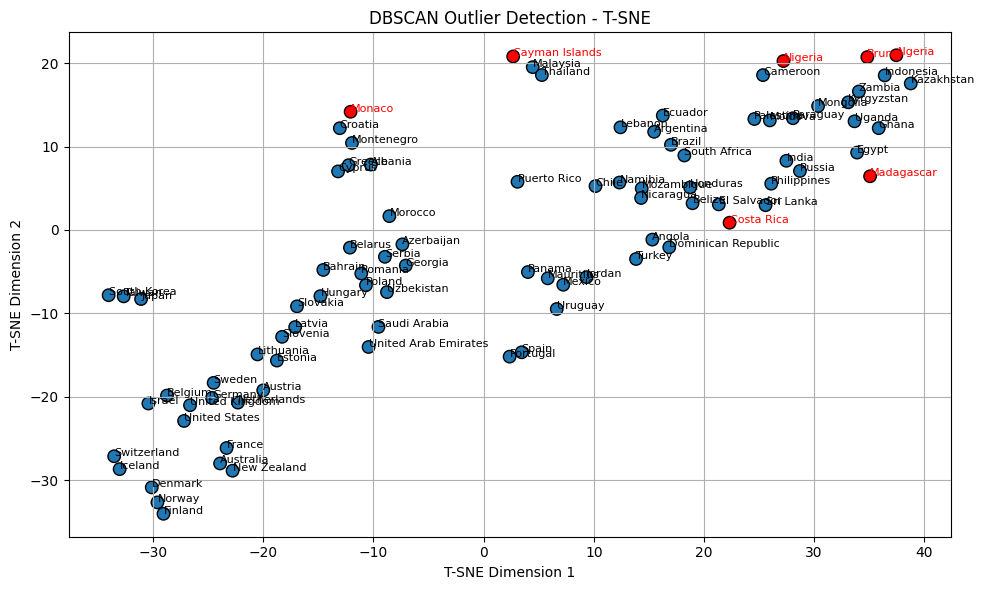


 Outlier Countries Detected:
       CountryName CountryCode
1          Algeria         DZA
12          Brunei         BRN
14  Cayman Islands         CYM
16      Costa Rica         CRI
44      Madagascar         MDG
49          Monaco         MCO
58         Nigeria         NGA

 Cleaned dataset contains 82 countries (out of 89)


In [8]:
from sklearn.cluster import DBSCAN
from sklearn.discriminant_analysis import StandardScaler


features = df.drop(columns=["CountryName", "CountryCode"])
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

eps_value = 3.5          
min_samples_value = 2    

dbscan = DBSCAN(eps=eps_value, min_samples=min_samples_value)
labels = dbscan.fit_predict(scaled_features)

# PCA Visualization
pca = PCA(n_components=2)
pca_components = pca.fit_transform(scaled_features)

plt.figure(figsize=(10, 6))
colors = ['#1f77b4' if label != -1 else '#ff0000' for label in labels]
plt.scatter(pca_components[:, 0], pca_components[:, 1], c=colors, s=80, edgecolors='k')

for i, country in enumerate(df["CountryName"]):
    color = 'red' if labels[i] == -1 else 'black'
    plt.annotate(country, (pca_components[i, 0], pca_components[i, 1]), fontsize=8, color=color)

plt.title("DBSCAN Outlier Detection - PCA")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid(True)
plt.tight_layout()
plt.show()

# T-SNE Visualization
tsne = TSNE(n_components=2, perplexity=5, random_state=42)
tsne_components = tsne.fit_transform(scaled_features)

plt.figure(figsize=(10, 6))
plt.scatter(tsne_components[:, 0], tsne_components[:, 1], c=colors, s=80, edgecolors='k')

for i, country in enumerate(df["CountryName"]):
    color = 'red' if labels[i] == -1 else 'black'
    plt.annotate(country, (tsne_components[i, 0], tsne_components[i, 1]), fontsize=8, color=color)

plt.title("DBSCAN Outlier Detection - T-SNE")
plt.xlabel("T-SNE Dimension 1")
plt.ylabel("T-SNE Dimension 2")
plt.grid(True)
plt.tight_layout()
plt.show()

# List outlier countries
outlier_countries = df[labels == -1][["CountryName", "CountryCode"]]
print("\n Outlier Countries Detected:")
print(outlier_countries)

# Create cleaned dataset
outlier_df = df[labels != -1].copy()
print(f"\n Cleaned dataset contains {len(outlier_df)} countries (out of {len(df)})")